![Title slide](title_slide.png)

# 1. Introduction

Online news platforms rely heavily on user engagement to drive visibility, advertising revenue, and audience reach. One of the most widely used indicators of engagement is the number of times an article is shared on social media. Being able to predict an article’s popularity before publication is valuable for media companies, editors, and content strategists, yet it remains a challenging task due to the complex and often unpredictable nature of human behavior.

In this project, we formulate **a supervised regression problem** aimed at predicting the number of shares an online news article will receive. We use the **Online News Popularity dataset**, publicly available from the **UCI Machine Learning Repository** ([link](https://archive.ics.uci.edu/dataset/332/online+news+popularity)), which contains information on nearly 40,000 news articles published by *Mashable*. The dataset provides a rich set of features describing article content, sentiment, timing, and structure.

The target variable, `shares`, represents the total number of times an article was shared across multiple social media platforms. The feature set includes, among others, statistics related to word usage, sentiment polarity, presence of multimedia content, keyword metrics, and publication day. Due to the highly skewed distribution of the target variable, careful preprocessing and evaluation are required to obtain reliable and interpretable models.

The main objectives of this project are:
- To explore and preprocess the dataset in a reproducible and well-documented manner,
- To train and tune multiple regression models with different levels of complexity,
- To compare model performance using appropriate regression metrics,
- To analyze prediction errors and understand model limitations,
- To reflect on ethical considerations related to popularity-based prediction systems.

To address these objectives, we experiment with **three regression algorithms**. 

# 2. Data Preprocessing

In [177]:
# Libraries import
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
import math
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
from sklearn.model_selection import RandomizedSearchCV
import matplotlib.pyplot as plt
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from xgboost import XGBRegressor



In [178]:
csv_path = 'OnlineNewsPopularity.csv'

df = pd.read_csv(csv_path)
print(f'Loaded local file: {csv_path}')
display(df.head())


Loaded local file: OnlineNewsPopularity.csv


,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


In [179]:
# Show column names cleanly
cols = df.columns.tolist()
print("Number of columns:", len(cols))
for c in cols:
    print(repr(c))

Number of columns: 61
'url'
' timedelta'
' n_tokens_title'
' n_tokens_content'
' n_unique_tokens'
' n_non_stop_words'
' n_non_stop_unique_tokens'
' num_hrefs'
' num_self_hrefs'
' num_imgs'
' num_videos'
' average_token_length'
' num_keywords'
' data_channel_is_lifestyle'
' data_channel_is_entertainment'
' data_channel_is_bus'
' data_channel_is_socmed'
' data_channel_is_tech'
' data_channel_is_world'
' kw_min_min'
' kw_max_min'
' kw_avg_min'
' kw_min_max'
' kw_max_max'
' kw_avg_max'
' kw_min_avg'
' kw_max_avg'
' kw_avg_avg'
' self_reference_min_shares'
' self_reference_max_shares'
' self_reference_avg_sharess'
' weekday_is_monday'
' weekday_is_tuesday'
' weekday_is_wednesday'
' weekday_is_thursday'
' weekday_is_friday'
' weekday_is_saturday'
' weekday_is_sunday'
' is_weekend'
' LDA_00'
' LDA_01'
' LDA_02'
' LDA_03'
' LDA_04'
' global_subjectivity'
' global_sentiment_polarity'
' global_rate_positive_words'
' global_rate_negative_words'
' rate_positive_words'
' rate_negative_words'
' avg_

The dataset contains **61 variables**, including one target variable (`shares`) and a rich set of features describing article content, metadata, publication timing, and sentiment. For clarity, the features are grouped into meaningful categories below.


#### 1. Identifiers and Non-Predictive Features

- **`url`**: URL of the article (identifier, non-predictive)
- **`timedelta`**: Number of days between article publication and dataset acquisition (non-predictive)

These variables are excluded from modeling as they do not contain information available at prediction time or do not contribute to predicting popularity.


#### 2. Content Structure and Length Features

- **`n_tokens_title`**: Number of words in the article title  
- **`n_tokens_content`**: Number of words in the article content  
- **`average_token_length`**: Average word length in the content  
- **`num_keywords`**: Number of keywords in the article metadata  

These features capture the **length and structural complexity** of the article.


#### 3. Lexical Diversity and Text Composition

- **`n_unique_tokens`**: Proportion of unique words in the content  
- **`n_non_stop_words`**: Proportion of non-stop words  
- **`n_non_stop_unique_tokens`**: Proportion of unique non-stop words  

These variables describe **lexical richness and vocabulary diversity**, which may influence reader engagement.


#### 4. Hyperlinks and Multimedia Content

- **`num_hrefs`**: Number of external links in the article  
- **`num_self_hrefs`**: Number of links to other Mashable articles  
- **`num_imgs`**: Number of images  
- **`num_videos`**: Number of embedded videos  

These features reflect **content richness and interactivity**.


#### 5. Data Channel Indicators

Binary variables indicating the article’s category:

- **`data_channel_is_lifestyle`**
- **`data_channel_is_entertainment`**
- **`data_channel_is_bus`**
- **`data_channel_is_socmed`**
- **`data_channel_is_tech`**
- **`data_channel_is_world`**

These variables capture thematic differences that may affect popularity.


#### 6. Keyword Popularity Statistics

Statistics describing the popularity of keywords associated with the article:

- **Worst-performing keywords**:  
  - `kw_min_min`, `kw_max_min`, `kw_avg_min`
- **Best-performing keywords**:  
  - `kw_min_max`, `kw_max_max`, `kw_avg_max`
- **Average keyword performance**:  
  - `kw_min_avg`, `kw_max_avg`, `kw_avg_avg`

These features summarize historical keyword performance in terms of shares.


#### 7. Self-Reference Popularity Features

- **`self_reference_min_shares`**: Minimum shares of referenced Mashable articles  
- **`self_reference_max_shares`**: Maximum shares of referenced Mashable articles  
- **`self_reference_avg_sharess`**: Average shares of referenced Mashable articles  

These variables capture **internal popularity signals** based on related content.


#### 8. Publication Timing Features

- **Weekday indicators**:  
  - `weekday_is_monday`, `weekday_is_tuesday`, `weekday_is_wednesday`,  
    `weekday_is_thursday`, `weekday_is_friday`, `weekday_is_saturday`, `weekday_is_sunday`
- **`is_weekend`**: Indicates whether the article was published on a weekend  

These features model **temporal effects** in content popularity.


#### 9. Topic Distribution (LDA Features)

- **`LDA_00` – `LDA_04`**: Degree of association with five latent topics derived using Latent Dirichlet Allocation (LDA)

These variables describe the **thematic composition** of the article.


#### 10. Sentiment and Subjectivity Features (Content)

- **`global_subjectivity`**: Overall text subjectivity  
- **`global_sentiment_polarity`**: Overall sentiment polarity  
- **`global_rate_positive_words`**: Proportion of positive words  
- **`global_rate_negative_words`**: Proportion of negative words  
- **`rate_positive_words`**: Proportion of positive words among non-neutral tokens  
- **`rate_negative_words`**: Proportion of negative words among non-neutral tokens  
- **Polarity statistics**:  
  - `avg_positive_polarity`, `min_positive_polarity`, `max_positive_polarity`  
  - `avg_negative_polarity`, `min_negative_polarity`, `max_negative_polarity`  

These features quantify the **emotional tone and intensity** of the article text.


#### 11. Sentiment and Subjectivity Features (Title)

- **`title_subjectivity`**: Subjectivity of the article title  
- **`title_sentiment_polarity`**: Sentiment polarity of the title  
- **`abs_title_subjectivity`**: Absolute subjectivity level of the title  
- **`abs_title_sentiment_polarity`**: Absolute sentiment polarity level of the title  

These variables focus specifically on the **emotional impact of the headline**.


#### 12. Target Variable

- **`shares`**: Number of times the article was shared on social media platforms  

This variable represents the **target** of the regression task and serves as a proxy for article popularity.

In [180]:
# Remove leading spaces from column names
df.columns = df.columns.str.strip()

In [181]:
# Basic checks
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)

# Missing values
missing = df.isna().sum().sort_values(ascending=False)
print("\nMissing values (top):\n", missing.head(10))

# Duplicates
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (39644, 61)

Columns: ['url', 'timedelta', 'n_tokens_title', 'n_tokens_content', 'n_unique_tokens', 'n_non_stop_words', 'n_non_stop_unique_tokens', 'num_hrefs', 'num_self_hrefs', 'num_imgs', 'num_videos', 'average_token_length', 'num_keywords', 'data_channel_is_lifestyle', 'data_channel_is_entertainment', 'data_channel_is_bus', 'data_channel_is_socmed', 'data_channel_is_tech', 'data_channel_is_world', 'kw_min_min', 'kw_max_min', 'kw_avg_min', 'kw_min_max', 'kw_max_max', 'kw_avg_max', 'kw_min_avg', 'kw_max_avg', 'kw_avg_avg', 'self_reference_min_shares', 'self_reference_max_shares', 'self_reference_avg_sharess', 'weekday_is_monday', 'weekday_is_tuesday', 'weekday_is_wednesday', 'weekday_is_thursday', 'weekday_is_friday', 'weekday_is_saturday', 'weekday_is_sunday', 'is_weekend', 'LDA_00', 'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04', 'global_subjectivity', 'global_sentiment_polarity', 'global_rate_positive_words', 'global_rate_negative_words', 'rate_positive_words', 'rate_negative_words

The dataset consists of **39,644 observations** and **61 variables**, including one target variable (`shares`) and a rich set of numerical and categorical features describing article content, sentiment, timing and structure.  
The dataset is fully populated, simplifying preprocessing and ensuring that modeling results are not influenced by missing-data handling strategies.

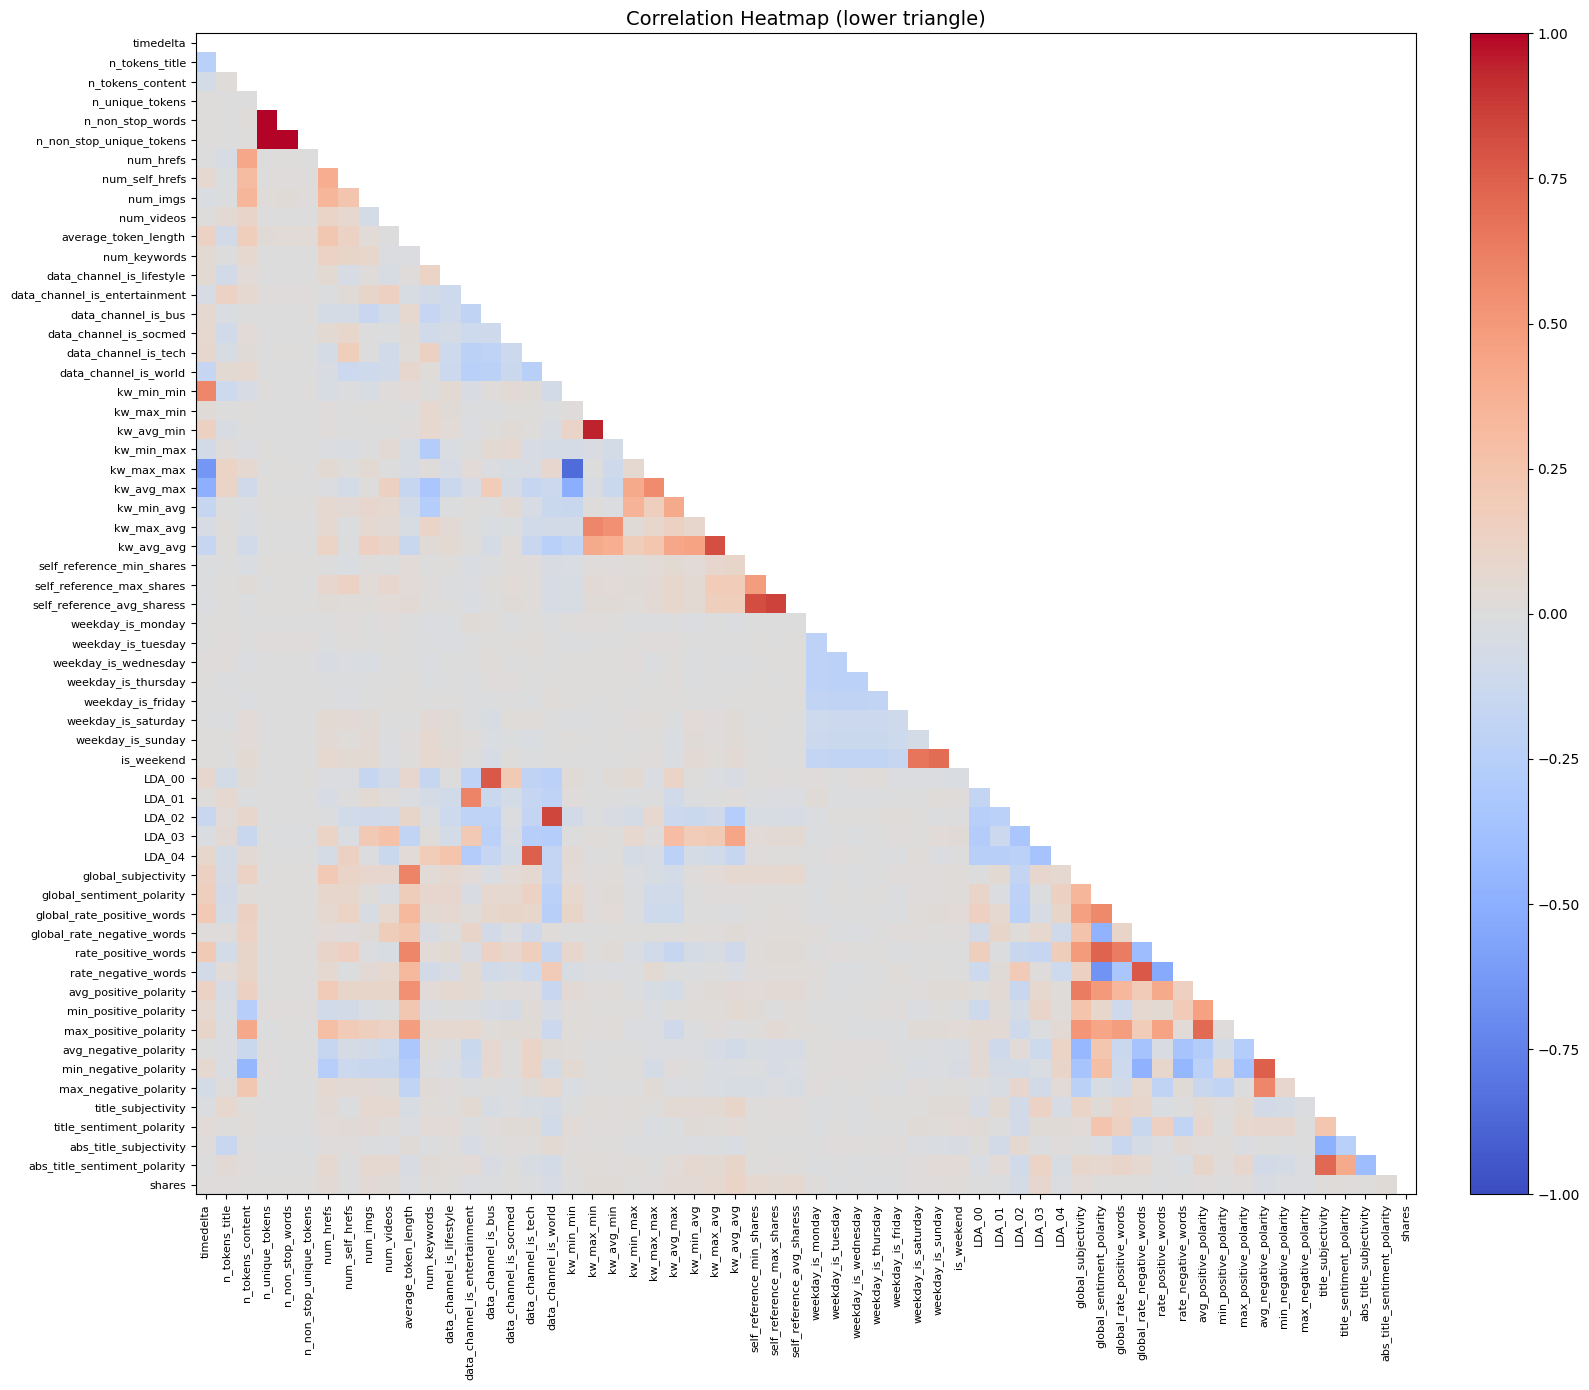

In [182]:
import matplotlib.pyplot as plt
import numpy as np

corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.imshow(np.ma.array(corr_matrix, mask=mask), cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(fraction=0.046, pad=0.04)
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90, fontsize=8)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index, fontsize=8)
plt.title("Correlation Heatmap (lower triangle)", fontsize=14)
plt.tight_layout()
plt.show()


# 3. Explanatory Data Analysis and Feature Engineering

### Correlation Heatmap

Let's check correlation heatmap.

In [183]:
corr_matrix = df.corr(numeric_only=True)

# Correlation with target
target_corr = corr_matrix["num_imgs"].sort_values(ascending=False)

display(target_corr.head(10))
display(target_corr.tail(10))

num_imgs                         1.000000
num_hrefs                        0.342633
n_tokens_content                 0.342600
num_self_hrefs                   0.238586
LDA_03                           0.208924
max_positive_polarity            0.155232
kw_avg_avg                       0.145236
data_channel_is_entertainment    0.099327
avg_positive_polarity            0.096446
num_keywords                     0.088432
Name: num_imgs, dtype: float64

timedelta                    -0.027636
global_rate_positive_words   -0.041582
kw_min_min                   -0.043840
num_videos                   -0.067336
avg_negative_polarity        -0.072500
LDA_02                       -0.094515
data_channel_is_world        -0.106480
min_negative_polarity        -0.136522
data_channel_is_bus          -0.142542
LDA_00                       -0.150439
Name: num_imgs, dtype: float64

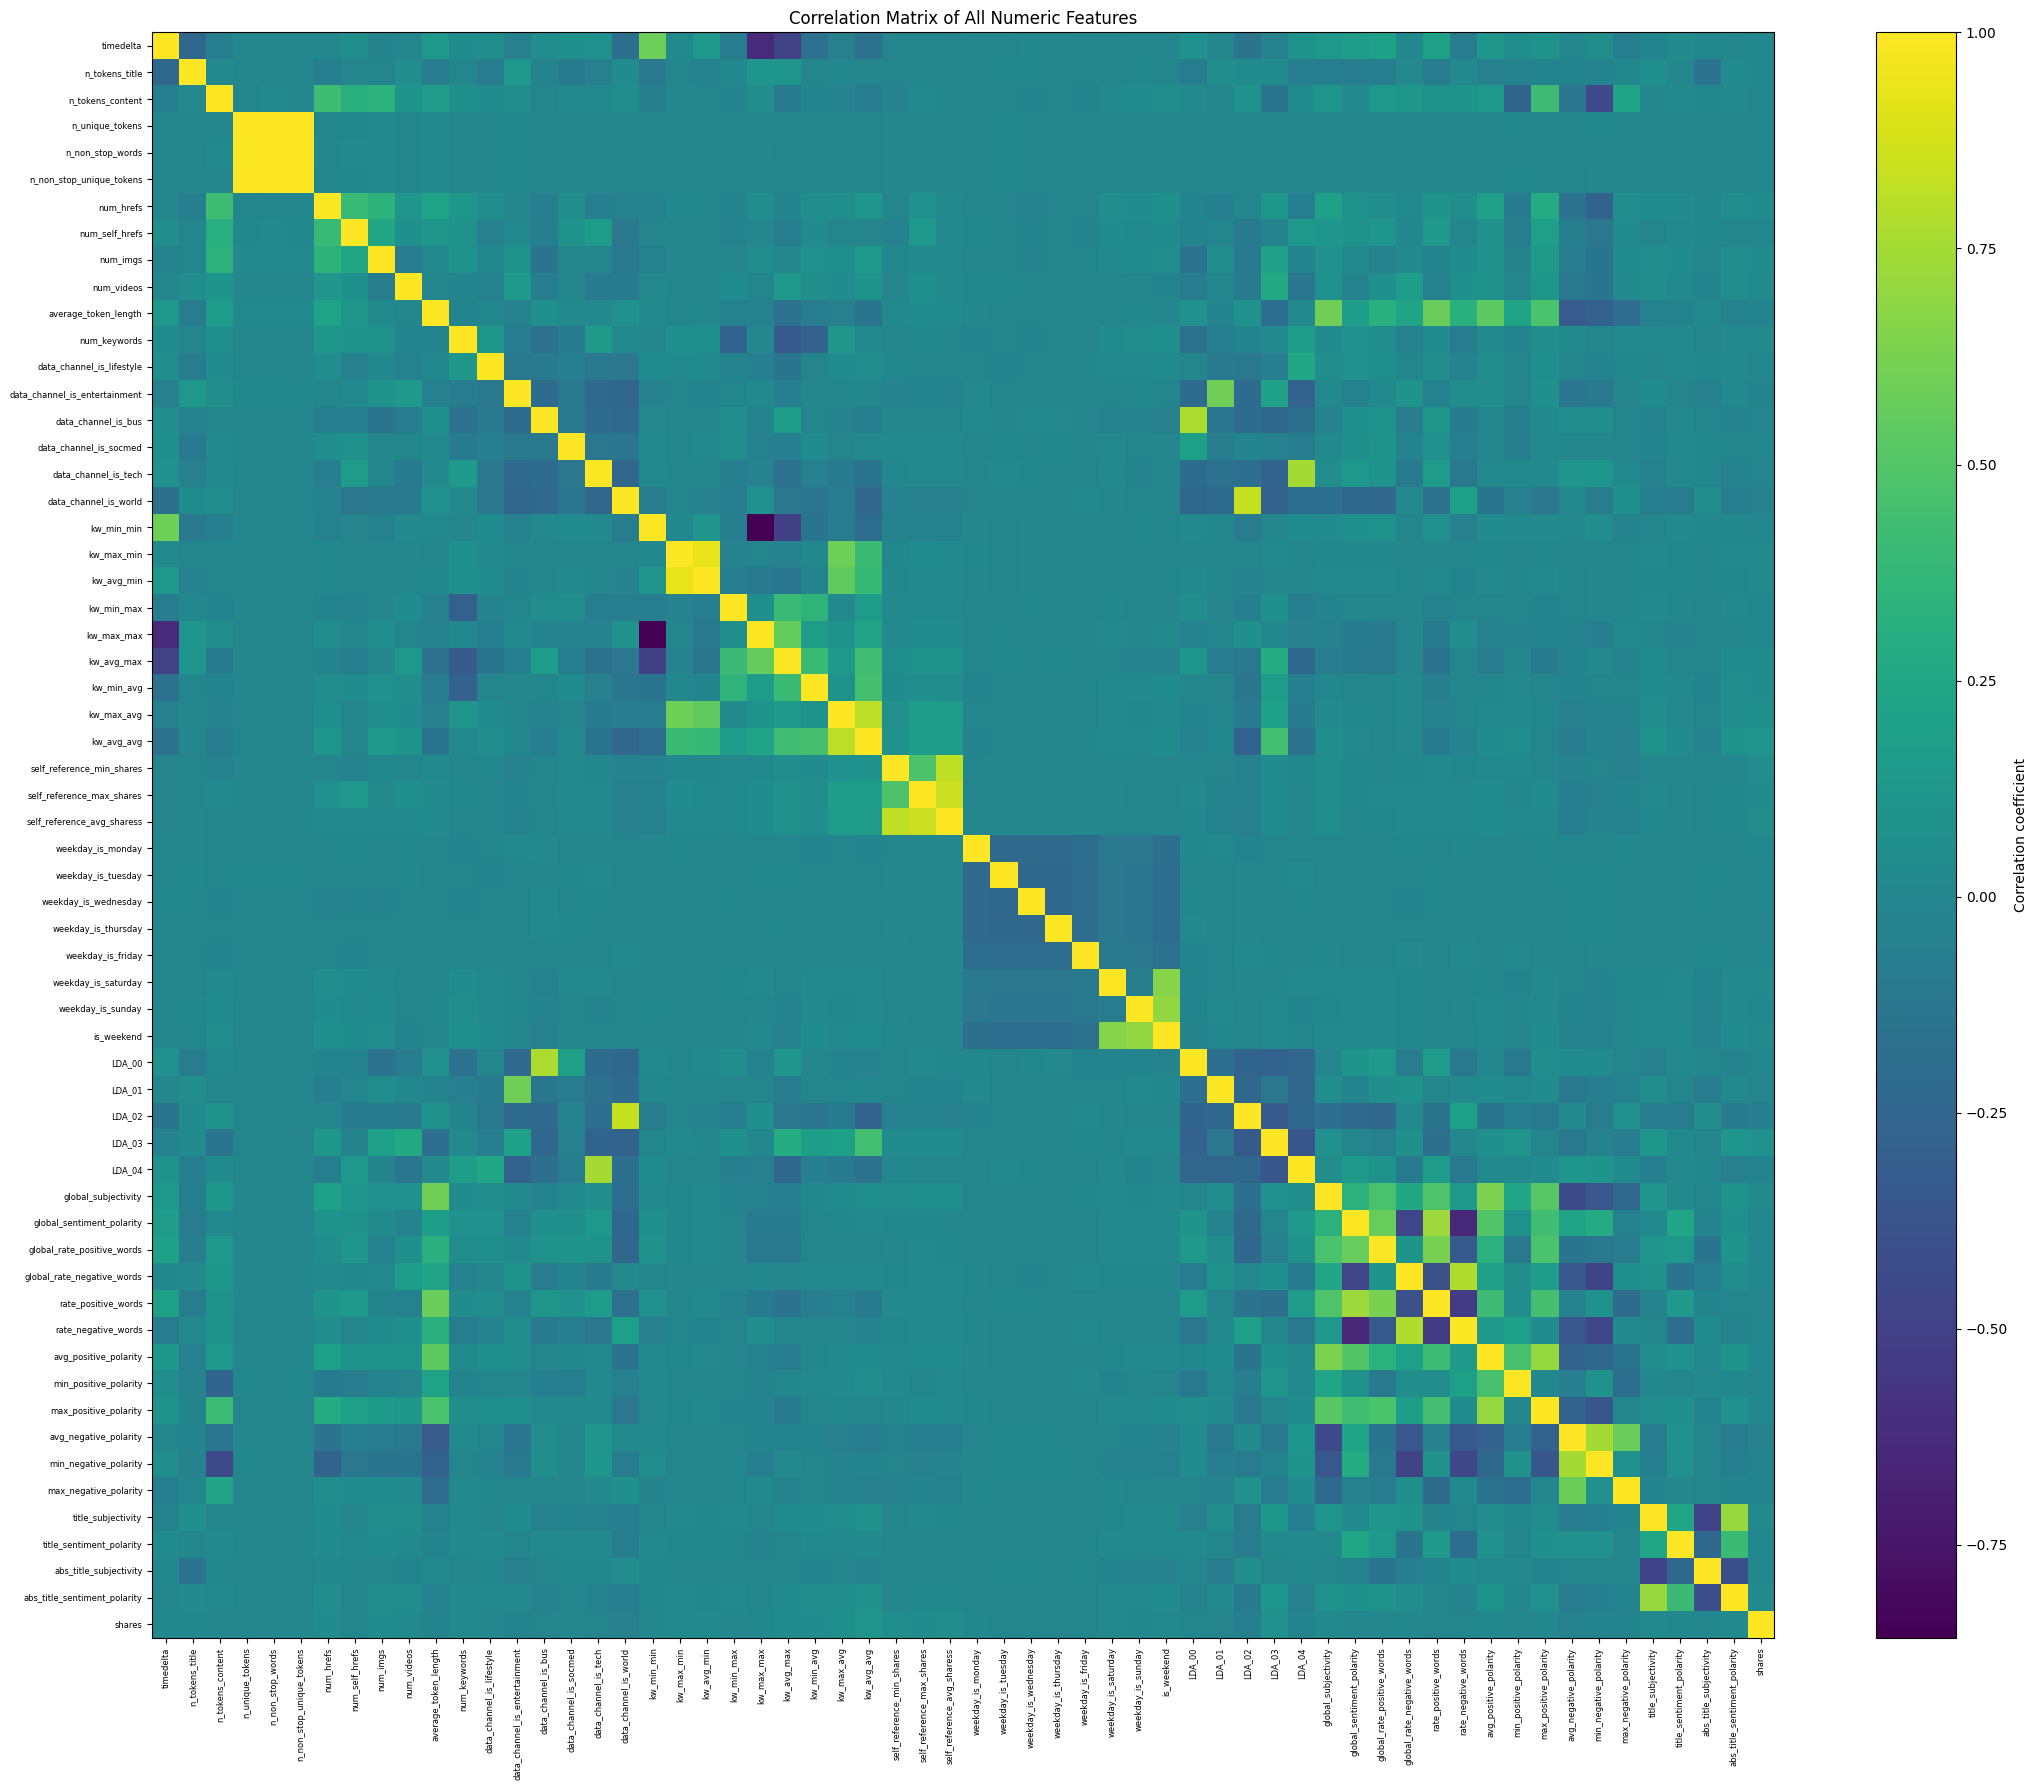

In [184]:
plt.figure(figsize=(22, 18))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlation coefficient")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90, fontsize=6)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns, fontsize=6)
plt.title("Correlation Matrix of All Numeric Features")
plt.tight_layout()
plt.show()

Feature aggregation was applied to groups of highly correlated variables identified during correlation analysis. By combining redundant features into representative summary measures, multicollinearity was reduced while preserving the underlying predictive information. This approach improves model stability, interpretability and computational efficiency without relying on aggressive manual feature removal.

We get rid of weekday and we will make it categorical and encode it later.

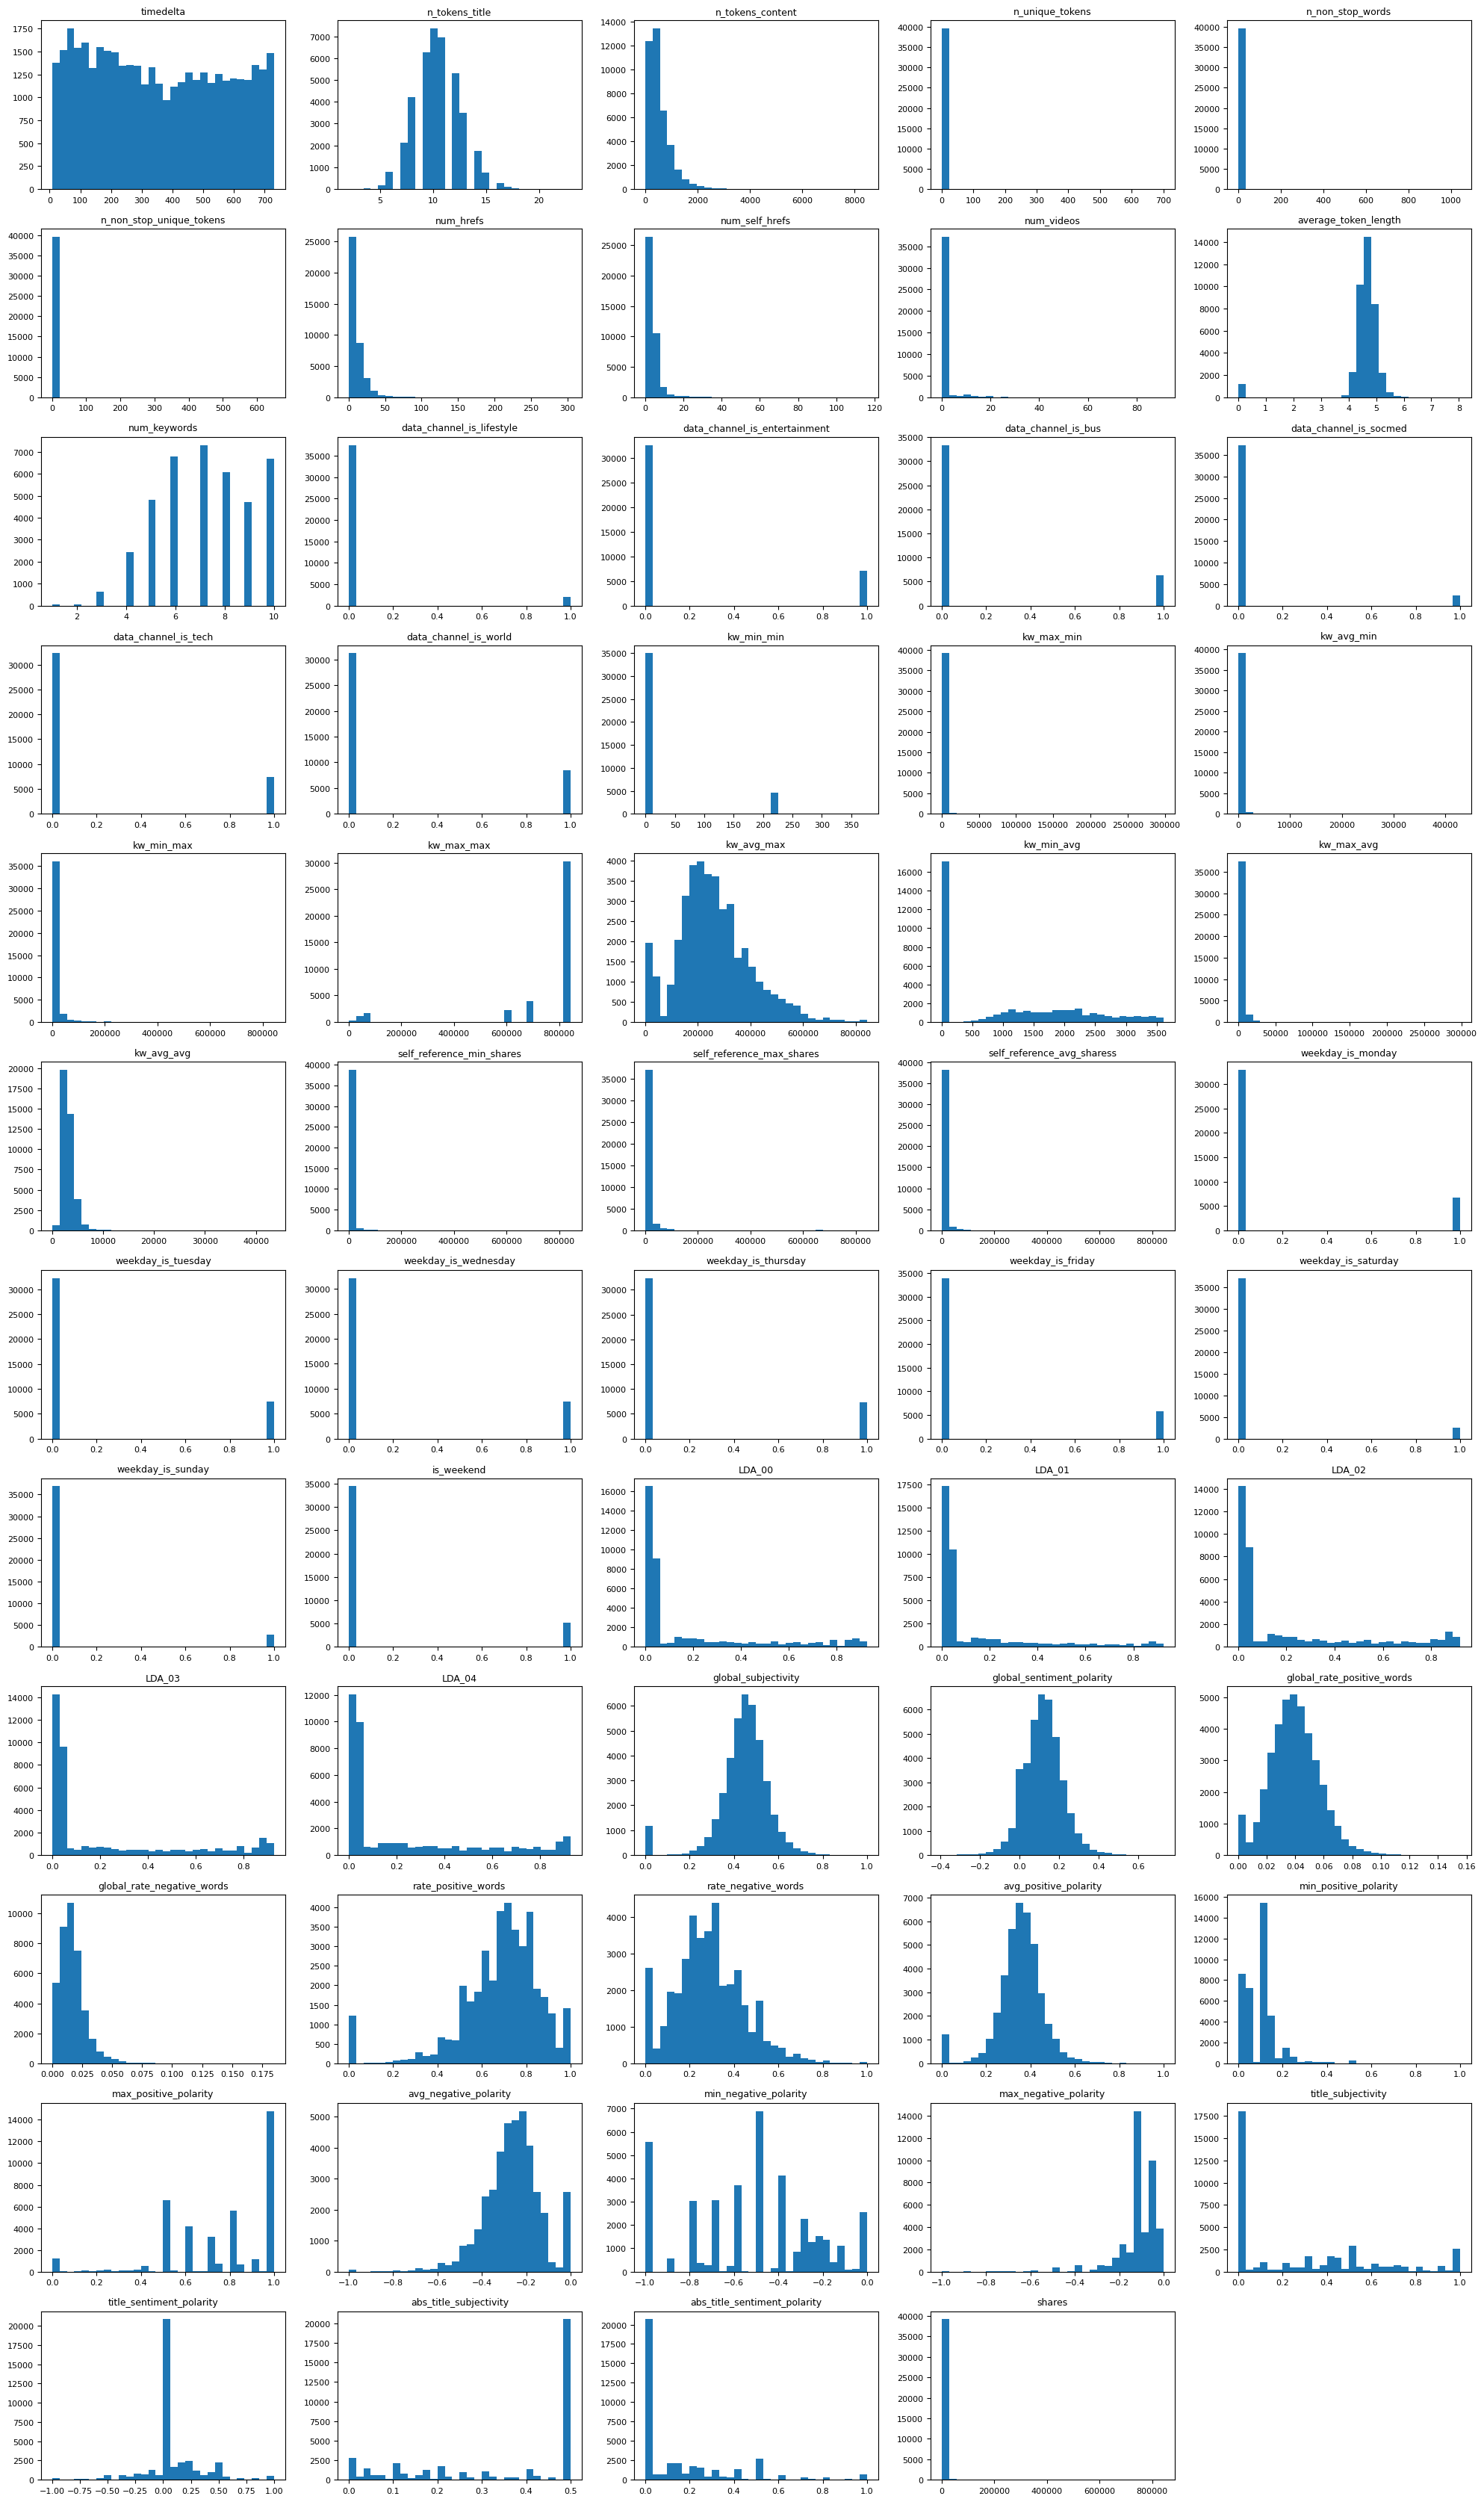

In [185]:
# Select numeric columns only, exclude target
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != "num_imgs"]  # predictors only

# Grid layout
n_cols = 5  
n_plots = len(numeric_cols)
n_rows = math.ceil(n_plots / n_cols)

# Create the figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 2.8*n_rows))
axes = axes.flatten()

# Plot each histogram
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=30)
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(axis="both", labelsize=8)

# Hide unused subplots (if any)
for j in range(n_plots, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [186]:
df.shape

(39644, 61)

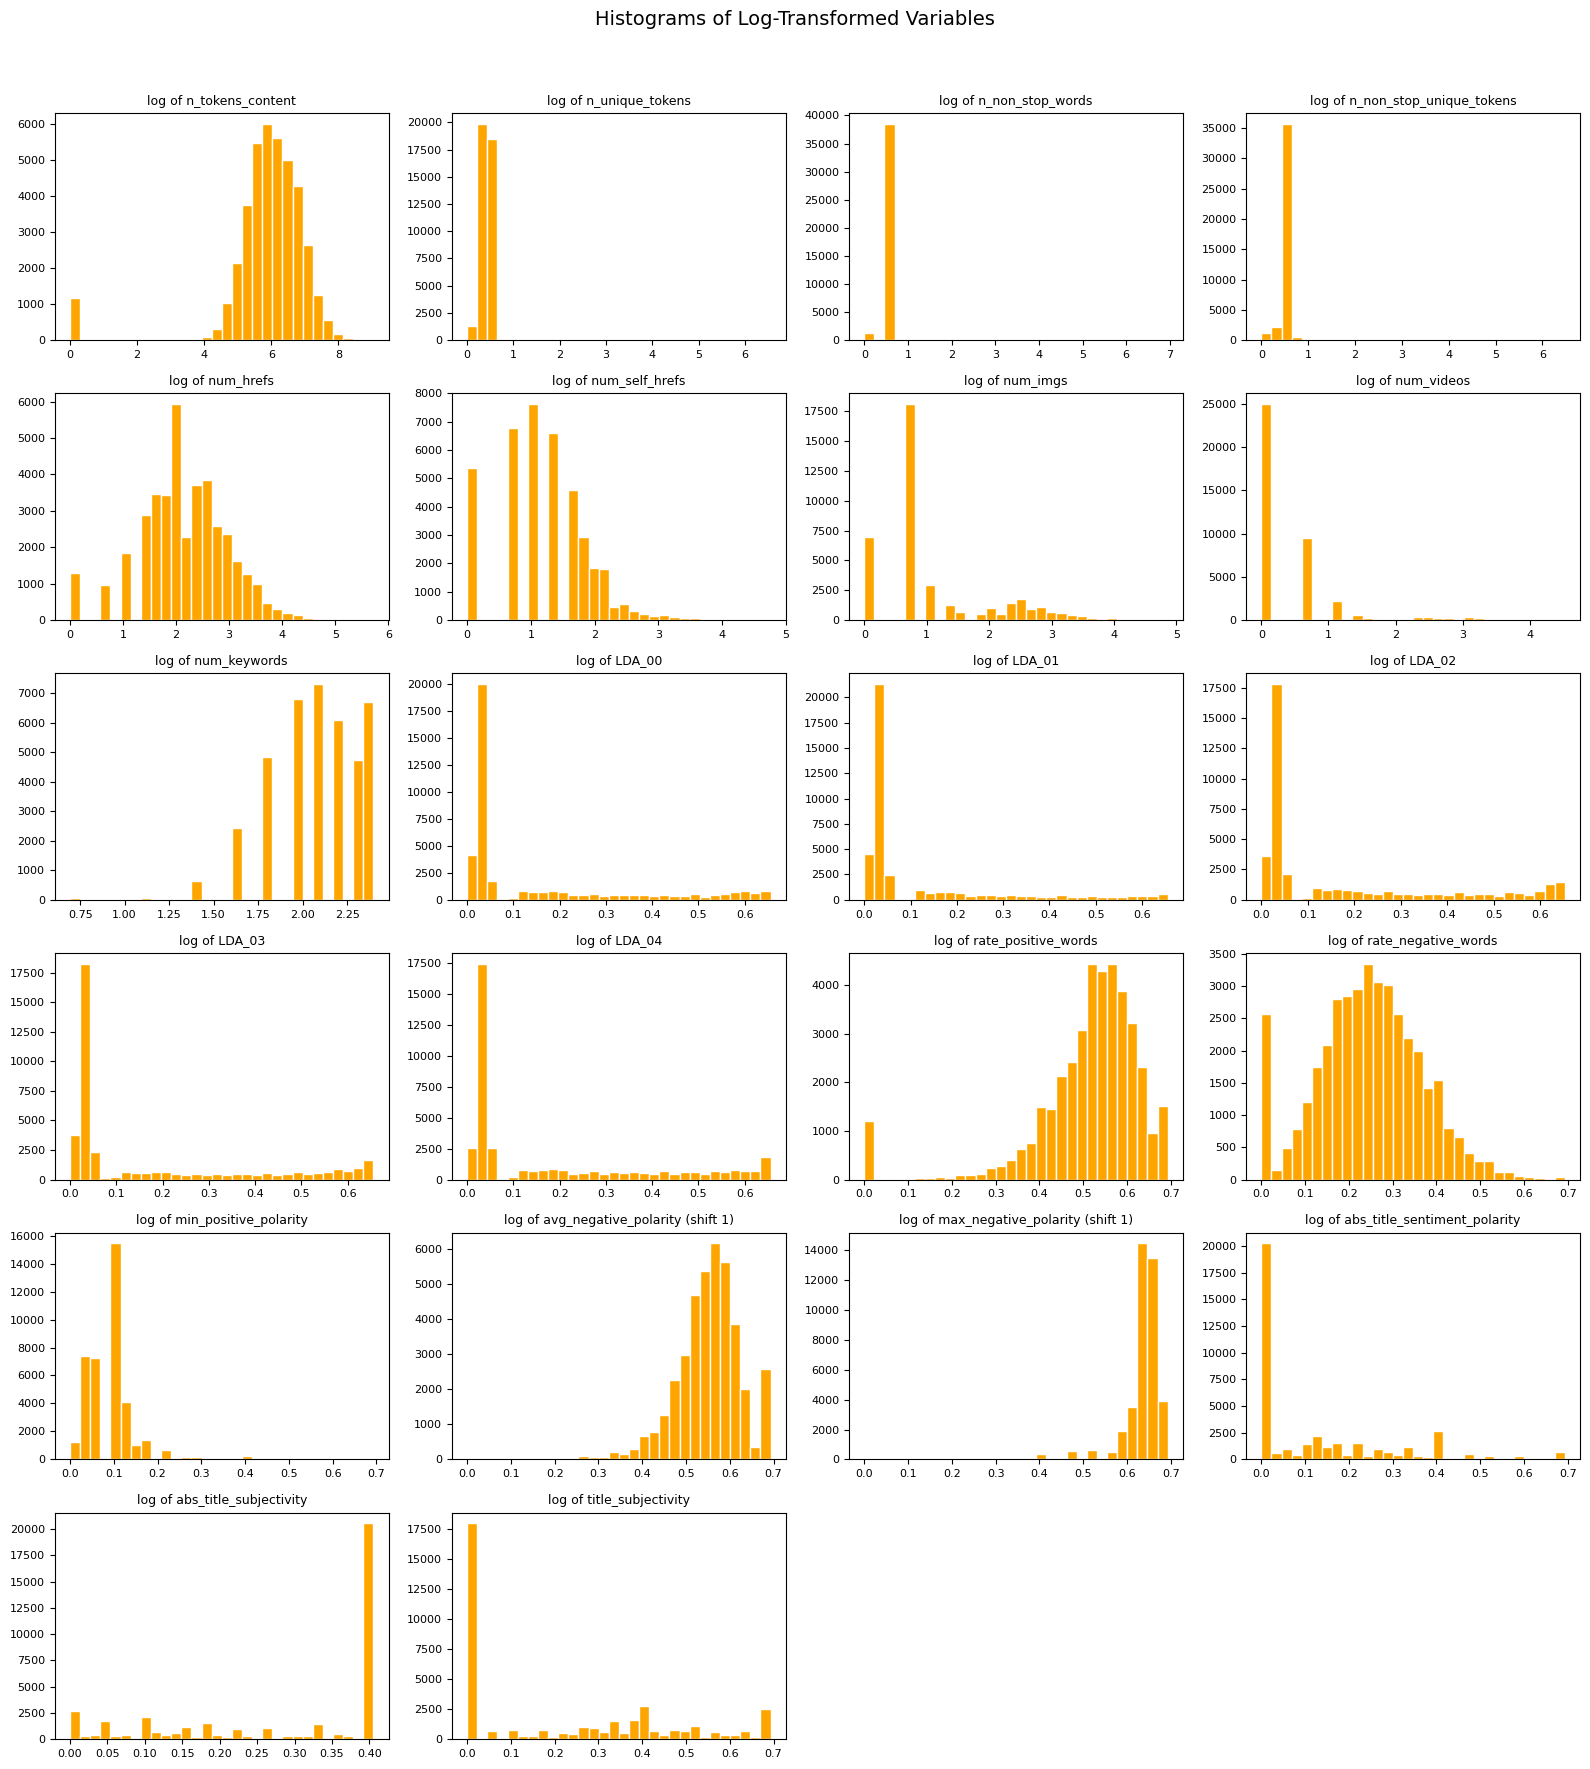

In [187]:
log_vars = [
    "n_tokens_content", "n_unique_tokens", "n_non_stop_words",
    "n_non_stop_unique_tokens", "num_hrefs", "num_self_hrefs",
    "num_imgs", "num_videos", "num_keywords",
    "LDA_00", "LDA_01", "LDA_02", "LDA_03", "LDA_04",
    "rate_positive_words", "rate_negative_words",
    "min_positive_polarity", "avg_negative_polarity", "max_negative_polarity",
    "kw_avg_mean", "kw_worst_mean","self_reference_mean_shares",
    "content_sentiment_strength", "content_polarity_range",
    "abs_title_sentiment_polarity", "abs_title_subjectivity",
    "content_sentiment_strength", "title_subjectivity"
]

log_vars = [c for c in log_vars if c in df.columns]

n_cols = 4
n_plots = len(log_vars)
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = np.array(axes).flatten()

for i, col in enumerate(log_vars):
    raw = df[col].dropna()

    # Shift if needed so all values are > -1 for log1p
    min_val = raw.min()
    shift = (-min_val + 1e-6) if min_val <= -1 else 0.0

    data = np.log1p(raw + shift)

    axes[i].hist(data, bins=30, color="orange", edgecolor="white")
    if shift > 0:
        axes[i].set_title(f"log of {col} (shift {shift:.3g})", fontsize=9)
    else:
        axes[i].set_title(f"log of {col}", fontsize=9)
    axes[i].tick_params(axis="both", labelsize=8)

for j in range(n_plots, len(axes)):
    axes[j].axis("off")

plt.suptitle("Histograms of Log-Transformed Variables", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [188]:
df

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.70,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.70,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.00,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.136364,0.80,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.033333,1.00,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39639,http://mashable.com/2014/12/27/samsung-app-aut...,8.0,11.0,346.0,0.529052,1.0,0.684783,9.0,7.0,1.0,...,0.100000,0.75,-0.260000,-0.500,-0.125000,0.100000,0.000000,0.400000,0.000000,1800
39640,http://mashable.com/2014/12/27/seth-rogen-jame...,8.0,12.0,328.0,0.696296,1.0,0.885057,9.0,7.0,3.0,...,0.136364,0.70,-0.211111,-0.400,-0.100000,0.300000,1.000000,0.200000,1.000000,1900
39641,http://mashable.com/2014/12/27/son-pays-off-mo...,8.0,10.0,442.0,0.516355,1.0,0.644128,24.0,1.0,12.0,...,0.136364,0.50,-0.356439,-0.800,-0.166667,0.454545,0.136364,0.045455,0.136364,1900
39642,http://mashable.com/2014/12/27/ukraine-blasts/,8.0,6.0,682.0,0.539493,1.0,0.692661,10.0,1.0,1.0,...,0.062500,0.50,-0.205246,-0.500,-0.012500,0.000000,0.000000,0.500000,0.000000,1100


In [189]:
# Drop specified (possibly already-removed) columns safely and report outcome
cols_to_drop = [
    "url",
    "timedelta",
    "n_unique_tokens",
    "n_non_stop_words",
    "n_non_stop_unique_tokens",
    "num_videos",
    "num_self_hrefs",
    "LDA_00",
    "LDA_01",
    "LDA_02",
    "LDA_03",
    "LDA_04",
    "min_positive_polarity",
    "max_negative_polarity",
    "rate_negative_words",
    "content_polarity_range",
    "abs_title_sentiment_polarity",
    "abs_title_subjectivity",
    "title_subjectivity"
]
existing = [c for c in cols_to_drop if c in df.columns]
missing = [c for c in cols_to_drop if c not in df.columns]

if existing:
    df.drop(columns=existing, inplace=True, errors="ignore")

print(f"Dropped columns ({len(existing)}): {existing}")
if missing:
    print(f"Ignored (not present): {missing}")
print("New dataframe shape:", df.shape)

Dropped columns (18): ['url', 'timedelta', 'n_unique_tokens', 'n_non_stop_words', 'n_non_stop_unique_tokens', 'num_videos', 'num_self_hrefs', 'LDA_00', 'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04', 'min_positive_polarity', 'max_negative_polarity', 'rate_negative_words', 'abs_title_sentiment_polarity', 'abs_title_subjectivity', 'title_subjectivity']
Ignored (not present): ['content_polarity_range']
New dataframe shape: (39644, 43)


In [190]:
df

,n_tokens_title,n_tokens_content,num_hrefs,num_imgs,average_token_length,num_keywords,data_channel_is_lifestyle,data_channel_is_entertainment,data_channel_is_bus,data_channel_is_socmed,...,global_sentiment_polarity,global_rate_positive_words,global_rate_negative_words,rate_positive_words,avg_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,title_sentiment_polarity,shares
0,12.0,219.0,4.0,1.0,4.680365,5.0,0.0,1.0,0.0,0.0,...,0.092562,0.045662,0.013699,0.769231,0.378636,0.70,-0.350000,-0.600,-0.187500,593
1,9.0,255.0,3.0,1.0,4.913725,4.0,0.0,0.0,1.0,0.0,...,0.148948,0.043137,0.015686,0.733333,0.286915,0.70,-0.118750,-0.125,0.000000,711
2,9.0,211.0,3.0,1.0,4.393365,6.0,0.0,0.0,1.0,0.0,...,0.323333,0.056872,0.009479,0.857143,0.495833,1.00,-0.466667,-0.800,0.000000,1500
3,9.0,531.0,9.0,1.0,4.404896,7.0,0.0,1.0,0.0,0.0,...,0.100705,0.041431,0.020716,0.666667,0.385965,0.80,-0.369697,-0.600,0.000000,1200
4,13.0,1072.0,19.0,20.0,4.682836,7.0,0.0,0.0,0.0,0.0,...,0.281003,0.074627,0.012127,0.860215,0.411127,1.00,-0.220192,-0.500,0.136364,505
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39639,11.0,346.0,9.0,1.0,4.523121,8.0,0.0,0.0,0.0,0.0,...,0.141964,0.037572,0.014451,0.722222,0.333791,0.75,-0.260000,-0.500,0.000000,1800
39640,12.0,328.0,9.0,3.0,4.405488,7.0,0.0,0.0,0.0,1.0,...,0.194249,0.039634,0.009146,0.812500,0.374825,0.70,-0.211111,-0.400,1.000000,1900
39641,10.0,442.0,24.0,12.0,5.076923,8.0,0.0,0.0,0.0,0.0,...,0.024609,0.033937,0.024887,0.576923,0.307273,0.50,-0.356439,-0.800,0.136364,1900
39642,6.0,682.0,10.0,1.0,4.975073,5.0,0.0,0.0,0.0,0.0,...,-0.008066,0.020528,0.023460,0.466667,0.236851,0.50,-0.205246,-0.500,0.000000,1100


### Target Variable Analysis

Shares is our target variable

In [191]:
# Summary of target
display(df["num_imgs"].describe())

count    39644.000000
mean         4.544143
std          8.309434
min          0.000000
25%          1.000000
50%          1.000000
75%          4.000000
max        128.000000
Name: num_imgs, dtype: float64

- The target variable, `shares`, displays a **highly right-skewed distribution**.
- The **median** number of shares is **1,400**, while the **mean** is substantially higher at **3,395**, indicating the presence of extreme values.
- The **standard deviation** (**11,627**) is more than three times the mean, reflecting **very high variability** in article popularity.
- The **maximum observed value** reaches **843,300 shares**, showing that a small number of articles achieve **viral popularity**, but they are perceived as outliers.
- In contrast, the majority of articles receive **relatively modest engagement**, with 75% of articles having fewer than **2,800 shares**.
- These characteristics motivate the use of a **logarithmic transformation of the target variable** in the modeling stage to reduce skewness and mitigate the influence of outliers.

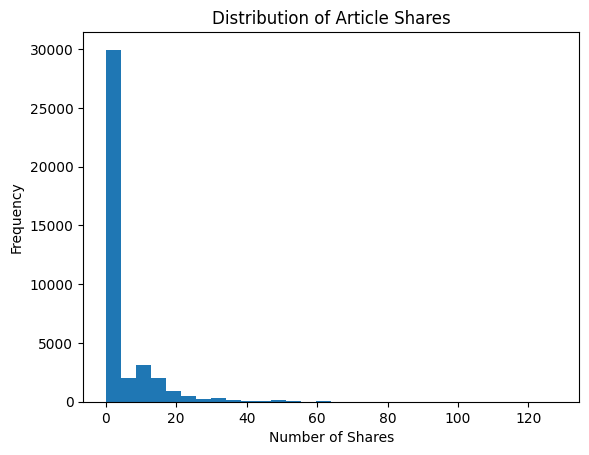

In [192]:
plt.figure()
plt.hist(df["num_imgs"], bins=30)
plt.xlabel("Number of Shares")
plt.ylabel("Frequency")
plt.title("Distribution of Article Shares")
plt.show()

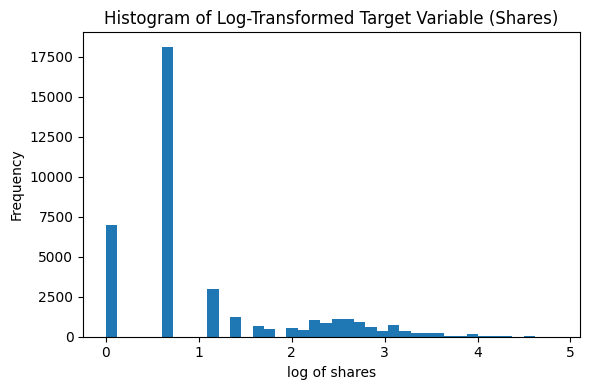

In [193]:
# Log-transform target for visualization
log_shares = np.log1p(df["num_imgs"])

plt.figure(figsize=(6, 4))
plt.hist(log_shares, bins=40)
plt.xlabel("log of shares")
plt.ylabel("Frequency")
plt.title("Histogram of Log-Transformed Target Variable (Shares)")
plt.tight_layout()
plt.show()

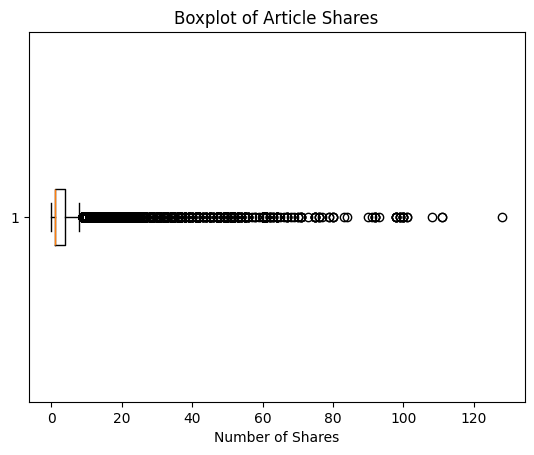

In [194]:
plt.figure()
plt.boxplot(df["num_imgs"], vert=False)
plt.xlabel("Number of Shares")
plt.title("Boxplot of Article Shares")
plt.show()

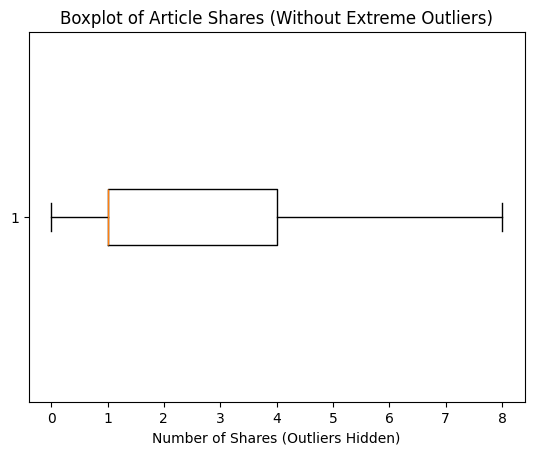

In [195]:
plt.figure()
plt.boxplot(df["num_imgs"], vert=False, showfliers=False)
plt.xlabel("Number of Shares (Outliers Hidden)")
plt.title("Boxplot of Article Shares (Without Extreme Outliers)")
plt.show()

In [196]:
# create log-transformed target in the dataframe
df["log_num_imgs"] = np.log1p(df["num_imgs"])

In [197]:
# Drop the raw target column 'shares' from the dataframe
if "num_imgs" in df.columns:
    df.drop(columns=["num_imgs"], inplace=True)
    print("Dropped 'shares'. New shape:", df.shape)
else:
    print("'shares' column not present; no action taken.")

# Quick check of remaining columns
print("Columns now:", df.columns.tolist())

Dropped 'shares'. New shape: (39644, 43)
Columns now: ['n_tokens_title', 'n_tokens_content', 'num_hrefs', 'average_token_length', 'num_keywords', 'data_channel_is_lifestyle', 'data_channel_is_entertainment', 'data_channel_is_bus', 'data_channel_is_socmed', 'data_channel_is_tech', 'data_channel_is_world', 'kw_min_min', 'kw_max_min', 'kw_avg_min', 'kw_min_max', 'kw_max_max', 'kw_avg_max', 'kw_min_avg', 'kw_max_avg', 'kw_avg_avg', 'self_reference_min_shares', 'self_reference_max_shares', 'self_reference_avg_sharess', 'weekday_is_monday', 'weekday_is_tuesday', 'weekday_is_wednesday', 'weekday_is_thursday', 'weekday_is_friday', 'weekday_is_saturday', 'weekday_is_sunday', 'is_weekend', 'global_subjectivity', 'global_sentiment_polarity', 'global_rate_positive_words', 'global_rate_negative_words', 'rate_positive_words', 'avg_positive_polarity', 'max_positive_polarity', 'avg_negative_polarity', 'min_negative_polarity', 'title_sentiment_polarity', 'shares', 'log_num_imgs']


### Predictor vs Target Variable

Content length vs Shares

In [198]:
df

,n_tokens_title,n_tokens_content,num_hrefs,average_token_length,num_keywords,data_channel_is_lifestyle,data_channel_is_entertainment,data_channel_is_bus,data_channel_is_socmed,data_channel_is_tech,...,global_rate_positive_words,global_rate_negative_words,rate_positive_words,avg_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,title_sentiment_polarity,shares,log_num_imgs
0,12.0,219.0,4.0,4.680365,5.0,0.0,1.0,0.0,0.0,0.0,...,0.045662,0.013699,0.769231,0.378636,0.70,-0.350000,-0.600,-0.187500,593,0.693147
1,9.0,255.0,3.0,4.913725,4.0,0.0,0.0,1.0,0.0,0.0,...,0.043137,0.015686,0.733333,0.286915,0.70,-0.118750,-0.125,0.000000,711,0.693147
2,9.0,211.0,3.0,4.393365,6.0,0.0,0.0,1.0,0.0,0.0,...,0.056872,0.009479,0.857143,0.495833,1.00,-0.466667,-0.800,0.000000,1500,0.693147
3,9.0,531.0,9.0,4.404896,7.0,0.0,1.0,0.0,0.0,0.0,...,0.041431,0.020716,0.666667,0.385965,0.80,-0.369697,-0.600,0.000000,1200,0.693147
4,13.0,1072.0,19.0,4.682836,7.0,0.0,0.0,0.0,0.0,1.0,...,0.074627,0.012127,0.860215,0.411127,1.00,-0.220192,-0.500,0.136364,505,3.044522
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39639,11.0,346.0,9.0,4.523121,8.0,0.0,0.0,0.0,0.0,1.0,...,0.037572,0.014451,0.722222,0.333791,0.75,-0.260000,-0.500,0.000000,1800,0.693147
39640,12.0,328.0,9.0,4.405488,7.0,0.0,0.0,0.0,1.0,0.0,...,0.039634,0.009146,0.812500,0.374825,0.70,-0.211111,-0.400,1.000000,1900,1.386294
39641,10.0,442.0,24.0,5.076923,8.0,0.0,0.0,0.0,0.0,0.0,...,0.033937,0.024887,0.576923,0.307273,0.50,-0.356439,-0.800,0.136364,1900,2.564949
39642,6.0,682.0,10.0,4.975073,5.0,0.0,0.0,0.0,0.0,0.0,...,0.020528,0.023460,0.466667,0.236851,0.50,-0.205246,-0.500,0.000000,1100,0.693147


##### Exploratory Data Analysis Summary

The exploratory analysis showed that the dataset contains no missing values and includes a large number of heterogeneous predictors. The target variable, number of shares, exhibits a highly right-skewed distribution, which motivated a logarithmic transformation. Several count-based predictors were also strongly right-skewed and were selected for logarithmic transformation. Correlation analysis revealed substantial redundancy among groups of features, leading to feature aggregation and more compact representations. Overall, individual predictors show weak to moderate relationships with the target, suggesting that article popularity depends on complex, non-linear interactions.

The histogram of `shares` reveals a strongly right-skewed distribution, with most articles receiving relatively few shares and a small number of viral articles forming a long right tail. This extreme skewness causes the majority of observations to cluster near the lower end of the distribution.

For better readibility, the boxplot without extreme outliers was created.

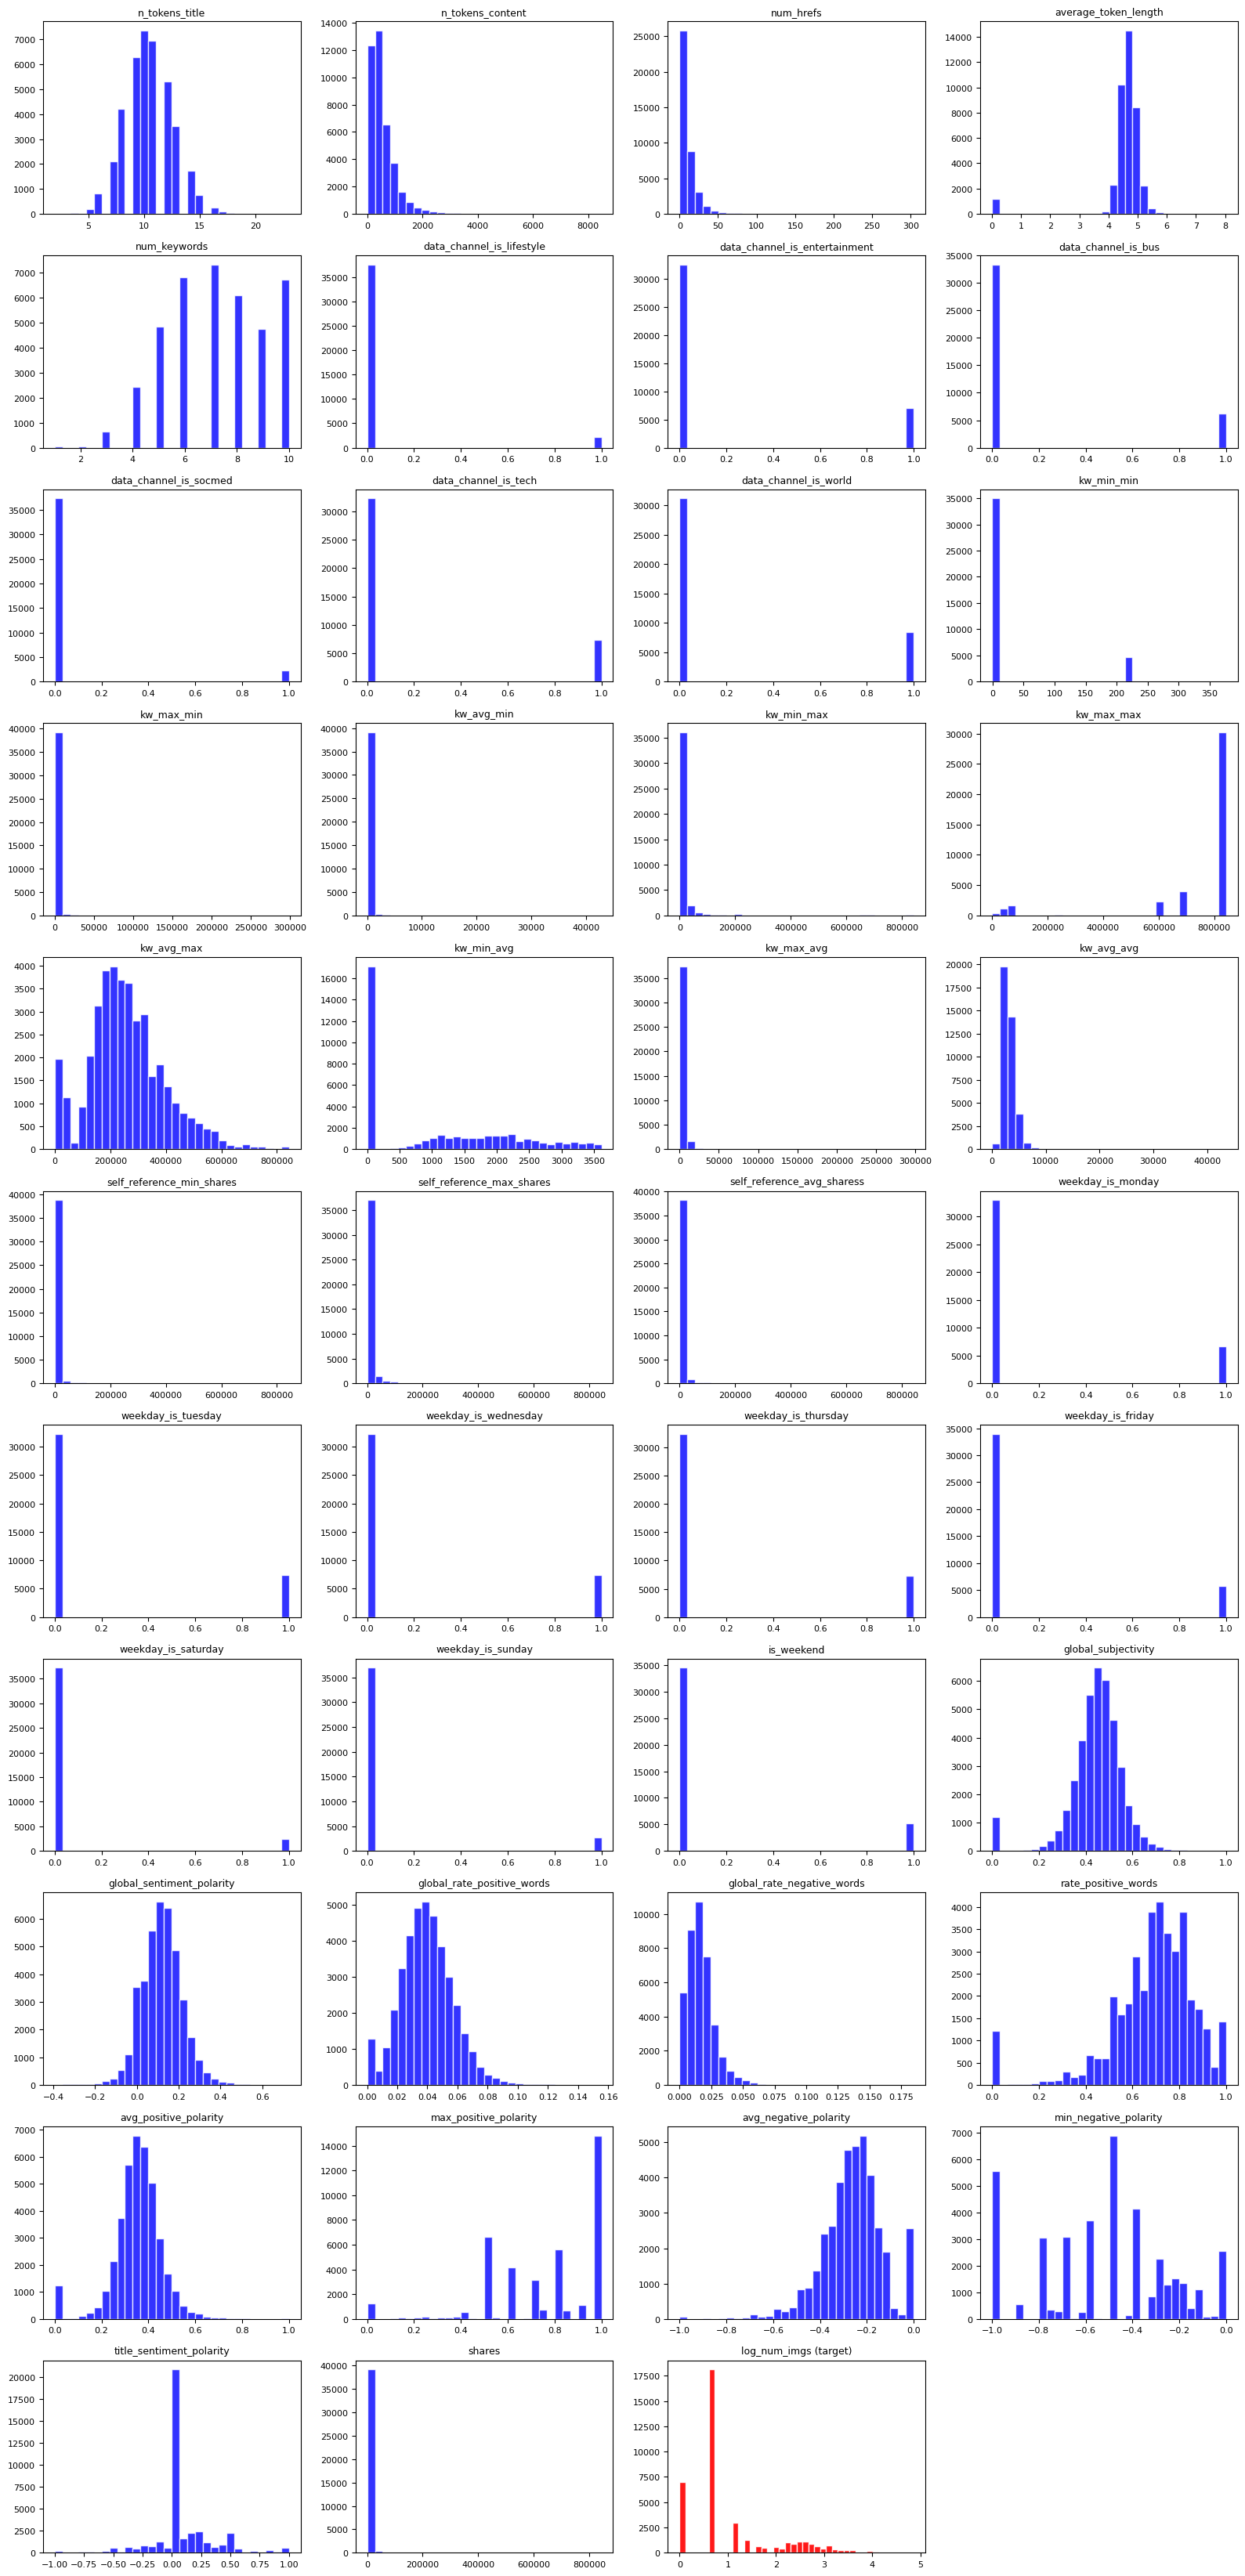

In [199]:
# Plot all features in a 4-column grid with color coding:
# - categorical: green
# - target 'log_shares': red
# - logarithmized features (start with 'log_'): orange
# - other numeric features: blue

cols = df.columns.tolist()
n_cols = 4
n_plots = len(cols)
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

cat_color = "green"
target_color = "red"
log_color = "orange"
num_color = "blue"

for i, col in enumerate(cols):
    ax = axes[i]
    series = df[col].dropna()

    if col == "log_num_imgs":
        # target (red)
        ax.hist(series, bins=40, color=target_color, edgecolor="white", alpha=0.9)
        ax.set_title(col + " (target)", fontsize=9)
    elif isinstance(df[col].dtype, np.dtype) and df[col].dtype == object:
        # categorical (green) -> bar plot of counts
        vc = series.value_counts().sort_index()
        ax.bar(vc.index.astype(str), vc.values, color=cat_color, alpha=0.8)
        ax.set_title(col + " (cat)", fontsize=9)
        ax.tick_params(axis="x", rotation=45)
    elif col.startswith("log_"):
        # log-transformed features (orange)
        ax.hist(series, bins=30, color=log_color, edgecolor="white", alpha=0.9)
        ax.set_title(col + " (log)", fontsize=9)
    else:
        # other numeric features (blue)
        ax.hist(series, bins=30, color=num_color, edgecolor="white", alpha=0.8)
        ax.set_title(col, fontsize=9)

    ax.tick_params(axis="both", labelsize=8)

# Hide any unused subplots
for j in range(n_plots, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [200]:
# Print current features in the dataframe `df`
all_columns = df.columns.tolist()

print("All columns (in df):")
for col in all_columns:
    print(f"- {col}")

df.shape

All columns (in df):
- n_tokens_title
- n_tokens_content
- num_hrefs
- average_token_length
- num_keywords
- data_channel_is_lifestyle
- data_channel_is_entertainment
- data_channel_is_bus
- data_channel_is_socmed
- data_channel_is_tech
- data_channel_is_world
- kw_min_min
- kw_max_min
- kw_avg_min
- kw_min_max
- kw_max_max
- kw_avg_max
- kw_min_avg
- kw_max_avg
- kw_avg_avg
- self_reference_min_shares
- self_reference_max_shares
- self_reference_avg_sharess
- weekday_is_monday
- weekday_is_tuesday
- weekday_is_wednesday
- weekday_is_thursday
- weekday_is_friday
- weekday_is_saturday
- weekday_is_sunday
- is_weekend
- global_subjectivity
- global_sentiment_polarity
- global_rate_positive_words
- global_rate_negative_words
- rate_positive_words
- avg_positive_polarity
- max_positive_polarity
- avg_negative_polarity
- min_negative_polarity
- title_sentiment_polarity
- shares
- log_num_imgs


(39644, 43)

In [201]:
# Encode categorical columns
categorical_features = [c for c in ["weekday", "data_channel"] if c in X_train.columns]
numeric_features = [c for c in X_train.columns if c not in categorical_features]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("scaler", StandardScaler()),
        ]), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
    ],
    remainder="drop"
)


### Train-Test Split

In [202]:
#Train / test split using log_shares as target
X = df.drop(columns=["log_num_imgs"])
y = df["log_num_imgs"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)

X_train: (31715, 42)
X_test:  (7929, 42)
y_train: (31715,)
y_test:  (7929,)


# 4. Modelling

In [203]:
df

,n_tokens_title,n_tokens_content,num_hrefs,average_token_length,num_keywords,data_channel_is_lifestyle,data_channel_is_entertainment,data_channel_is_bus,data_channel_is_socmed,data_channel_is_tech,...,global_rate_positive_words,global_rate_negative_words,rate_positive_words,avg_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,title_sentiment_polarity,shares,log_num_imgs
0,12.0,219.0,4.0,4.680365,5.0,0.0,1.0,0.0,0.0,0.0,...,0.045662,0.013699,0.769231,0.378636,0.70,-0.350000,-0.600,-0.187500,593,0.693147
1,9.0,255.0,3.0,4.913725,4.0,0.0,0.0,1.0,0.0,0.0,...,0.043137,0.015686,0.733333,0.286915,0.70,-0.118750,-0.125,0.000000,711,0.693147
2,9.0,211.0,3.0,4.393365,6.0,0.0,0.0,1.0,0.0,0.0,...,0.056872,0.009479,0.857143,0.495833,1.00,-0.466667,-0.800,0.000000,1500,0.693147
3,9.0,531.0,9.0,4.404896,7.0,0.0,1.0,0.0,0.0,0.0,...,0.041431,0.020716,0.666667,0.385965,0.80,-0.369697,-0.600,0.000000,1200,0.693147
4,13.0,1072.0,19.0,4.682836,7.0,0.0,0.0,0.0,0.0,1.0,...,0.074627,0.012127,0.860215,0.411127,1.00,-0.220192,-0.500,0.136364,505,3.044522
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39639,11.0,346.0,9.0,4.523121,8.0,0.0,0.0,0.0,0.0,1.0,...,0.037572,0.014451,0.722222,0.333791,0.75,-0.260000,-0.500,0.000000,1800,0.693147
39640,12.0,328.0,9.0,4.405488,7.0,0.0,0.0,0.0,1.0,0.0,...,0.039634,0.009146,0.812500,0.374825,0.70,-0.211111,-0.400,1.000000,1900,1.386294
39641,10.0,442.0,24.0,5.076923,8.0,0.0,0.0,0.0,0.0,0.0,...,0.033937,0.024887,0.576923,0.307273,0.50,-0.356439,-0.800,0.136364,1900,2.564949
39642,6.0,682.0,10.0,4.975073,5.0,0.0,0.0,0.0,0.0,0.0,...,0.020528,0.023460,0.466667,0.236851,0.50,-0.205246,-0.500,0.000000,1100,0.693147


## Random Forest

In [204]:
rf_model = Pipeline(steps=[
("model", RandomForestRegressor(
n_estimators=300,
random_state=42,
n_jobs=-1
))
])

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest RMSE: {rmse_rf:.3f}")
print(f"Random Forest R²: {r2_rf:.3f}")


Random Forest RMSE: 0.696
Random Forest R²: 0.486


In [205]:
from sklearn.ensemble import GradientBoostingRegressor
gbr_model = Pipeline(steps=[
    ("model", GradientBoostingRegressor(random_state=42))
])

gbr_model.fit(X_train, y_train)
y_pred_gbr = gbr_model.predict(X_test)

rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2_gbr = r2_score(y_test, y_pred_gbr)

print(f"Gradient Boosting RMSE: {rmse_gbr:.3f}")
print(f"Gradient Boosting R²: {r2_gbr:.3f}")


Gradient Boosting RMSE: 0.742
Gradient Boosting R²: 0.416


## Elastic Net

In [206]:
# Elastic Net model
en_model = Pipeline(steps=[
    ("model", ElasticNet(
        alpha=0.1,        
        l1_ratio=0.5,     # 0 = Ridge, 1 = Lasso, in-between = Elastic Net
        random_state=42,
        max_iter=10000   
    ))
])

# Fit model
en_model.fit(X_train, y_train)

# Predict on test set
y_pred_en = en_model.predict(X_test)

# Evaluation
rmse_en = np.sqrt(mean_squared_error(y_test, y_pred_en))
r2_en = r2_score(y_test, y_pred_en)

print(f"Elastic Net RMSE: {rmse_en:.3f}")
print(f"Elastic Net R²: {r2_en:.3f}")

Elastic Net RMSE: 0.859
Elastic Net R²: 0.215


## Support Vector Regression

In [207]:
# Baseline SVR model
svr_model = Pipeline(steps=[
    ("model", SVR(
        kernel="rbf",      # radial basis function kernel (default)
        C=1.0,             # regularization strength
        epsilon=0.1        # epsilon-insensitive tube
    ))
])

# Fit model
svr_model.fit(X_train, y_train)

# Predict on test set
y_pred_svr = svr_model.predict(X_test)

# Evaluation
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
r2_svr = r2_score(y_test, y_pred_svr)

print(f"SVR Baseline RMSE: {rmse_svr:.3f}")
print(f"SVR Baseline R²: {r2_svr:.3f}")

SVR Baseline RMSE: 1.001
SVR Baseline R²: -0.064


## XGBoost

In [208]:
# XGBoost model with the SAME preprocessing
xgb_model = Pipeline(steps=[
    ("model", XGBRegressor(
        n_estimators=500,        # number of trees
        learning_rate=0.05,      # step size (eta)
        max_depth=6,             # tree depth
        subsample=0.8,           # row sampling
        colsample_bytree=0.8,    # column sampling
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])

# Fit model
xgb_model.fit(X_train, y_train)

# Predict on test set
y_pred_xgb = xgb_model.predict(X_test)

# Evaluation
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost RMSE: {rmse_xgb:.3f}")
print(f"XGBoost R²: {r2_xgb:.3f}")

XGBoost RMSE: 0.683
XGBoost R²: 0.504


# 5. Hyperparameters Tuning

In [209]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

## Random Forest

In [210]:
rf_pipe = Pipeline(steps=[
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

param_dist = {
    "model__n_estimators": [200, 400, 600, 800],
    "model__max_depth": [None, 8, 12, 16, 20, 24],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.5],
    "model__max_samples": [None, 0.7, 0.85, 0.95],
}

search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=param_dist,
    n_iter=10,
    scoring={"rmse": make_scorer(rmse, greater_is_better=False), "r2": "r2"},
    refit="rmse",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print("Best params:", search.best_params_)

best_idx = search.best_index_
print("Best CV RMSE:", -search.best_score_)
print("Best CV R²:", search.cv_results_["mean_test_r2"][best_idx])

best_rf = search.best_estimator_
y_pred = best_rf.predict(X_test)
print("Test RMSE:", rmse(y_test, y_pred))
print("Test R²:", r2_score(y_test, y_pred))



Fitting 5 folds for each of 10 candidates, totalling 50 fits


KeyboardInterrupt: 

In [ ]:
rf_search = search
y_pred_rf = y_pred

rf_cv_rmse = -rf_search.best_score_
rf_cv_r2 = rf_search.cv_results_["mean_test_r2"][rf_search.best_index_]

rf_test_rmse = rmse(y_test, y_pred_rf)
rf_test_r2 = r2_score(y_test, y_pred_rf)

### Elastic Net

In [ ]:
enet_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", ElasticNet(random_state=42, max_iter=30000, tol=1e-4))
])

param_dist = {
    "model__alpha": np.logspace(-5, 1, 50),
    "model__l1_ratio": np.linspace(0.05, 1.0, 20),  # no 0
}

search = RandomizedSearchCV(
    enet_pipe,
    param_distributions=param_dist,
    n_iter=30,
    scoring={"rmse": make_scorer(rmse, greater_is_better=False), "r2": "r2"},
    refit="rmse",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

best_idx = search.best_index_
print("Best params:", search.best_params_)
print("Best CV RMSE:", -search.best_score_)
print("Best CV R²:", search.cv_results_["mean_test_r2"][best_idx])

best_enet = search.best_estimator_
y_pred = best_enet.predict(X_test)
print("Test RMSE:", rmse(y_test, y_pred))
print("Test R²:", r2_score(y_test, y_pred))


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'model__l1_ratio': np.float64(0.05), 'model__alpha': np.float64(0.0005179474679231213)}
Best CV RMSE: 0.8839019263688825
Best CV R²: 0.0976418373995889
Test RMSE: 0.8766727020146969
Test R²: 0.10341828573798806


In [ ]:
enet_search = search
y_pred_enet = y_pred

enet_cv_rmse = -enet_search.best_score_
enet_cv_r2 = enet_search.cv_results_["mean_test_r2"][enet_search.best_index_]

enet_test_rmse = rmse(y_test, y_pred_enet)
enet_test_r2 = r2_score(y_test, y_pred_enet)


### Support Vector Regression

In [ ]:
svr_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", SVR())
])

param_dist = {
    "model__kernel": ["rbf", "poly", "sigmoid"],
    "model__C": np.logspace(-2, 2, 10),
    "model__epsilon": [0.01, 0.05, 0.1, 0.2, 0.5],
    "model__gamma": ["scale", "auto"],
    "model__degree": [2, 3, 4],  # only used for poly
}

search = RandomizedSearchCV(
    svr_pipe,
    param_distributions=param_dist,
    n_iter=30,
    scoring={"rmse": make_scorer(rmse, greater_is_better=False), "r2": "r2"},
    refit="rmse",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

best_idx = search.best_index_
print("Best params:", search.best_params_)
print("Best CV RMSE:", -search.best_score_)
print("Best CV R²:", search.cv_results_["mean_test_r2"][best_idx])

best_svr = search.best_estimator_
y_pred = best_svr.predict(X_test)
print("Test RMSE:", rmse(y_test, y_pred))
print("Test R²:", r2_score(y_test, y_pred))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'model__kernel': 'rbf', 'model__gamma': 'auto', 'model__epsilon': 0.5, 'model__degree': 4, 'model__C': np.float64(0.5994842503189409)}
Best CV RMSE: 0.8695194022562888
Best CV R²: 0.12682828178484312
Test RMSE: 0.8625657443228641
Test R²: 0.1320407749825152


In [ ]:
svr_search = search
y_pred_svr = y_pred

svr_cv_rmse = -svr_search.best_score_
svr_cv_r2 = svr_search.cv_results_["mean_test_r2"][svr_search.best_index_]

svr_test_rmse = rmse(y_test, y_pred_svr)
svr_test_r2 = r2_score(y_test, y_pred_svr)


### XGBoost

In [ ]:
xgb_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", XGBRegressor(
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    ))
])

param_dist = {
    "model__n_estimators": [200, 400, 600, 800],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__reg_alpha": [0, 0.01, 0.1],
    "model__reg_lambda": [1.0, 1.5, 2.0],
}

search = RandomizedSearchCV(
    xgb_pipe,
    param_distributions=param_dist,
    n_iter=30,
    scoring={"rmse": make_scorer(rmse, greater_is_better=False), "r2": "r2"},
    refit="rmse",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

best_idx = search.best_index_
print("Best params:", search.best_params_)
print("Best CV RMSE:", -search.best_score_)
print("Best CV R²:", search.cv_results_["mean_test_r2"][best_idx])

best_xgb = search.best_estimator_
y_pred = best_xgb.predict(X_test)
print("Test RMSE:", rmse(y_test, y_pred))
print("Test R²:", r2_score(y_test, y_pred))


Fitting 5 folds for each of 30 candidates, totalling 150 fits


/Users/Weronika/Library/CloudStorage/OneDrive-Osobisty/Pulpit/Data-Science/Year 2 semester 3/Machine Learning 2/ML2_final_project/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'model__subsample': 0.7, 'model__reg_lambda': 1.0, 'model__reg_alpha': 0.01, 'model__n_estimators': 600, 'model__max_depth': 8, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.9}
Best CV RMSE: 0.8599416572766044
Best CV R²: 0.1459494829688142
Test RMSE: 0.8501644937630375
Test R²: 0.1568189523513599


In [ ]:
xgb_search = search
y_pred_xgb = y_pred

xgb_cv_rmse = -xgb_search.best_score_
xgb_cv_r2 = xgb_search.cv_results_["mean_test_r2"][xgb_search.best_index_]

xgb_test_rmse = rmse(y_test, y_pred_xgb)
xgb_test_r2 = r2_score(y_test, y_pred_xgb)


# 6. Models comparison

In [ ]:
baseline_table = pd.DataFrame({
    "model": ["Random Forest", "Elastic Net", "XGBoost", "SVR"],
    "rmse": [rmse_rf, rmse_en, rmse_xgb, rmse_svr],
    "r2":   [r2_rf, r2_en, r2_xgb, r2_svr],
}).set_index("model")

display(baseline_table.round(4))

,rmse,r2
model,,
Random Forest,0.8573,0.1426
Elastic Net,0.9070,0.0403
XGBoost,0.8584,0.1405
SVR,0.8768,0.1032


In [ ]:
def cv_test_row(name, search_obj):
    best_idx = search_obj.best_index_
    cv_rmse = -search_obj.best_score_
    cv_r2 = search_obj.cv_results_.get("mean_test_r2", [np.nan])[best_idx]

    best_model = search_obj.best_estimator_
    y_pred = best_model.predict(X_test)

    return {
        "model": name,
        "cv_rmse": cv_rmse,
        "cv_r2": cv_r2,
        "test_rmse": rmse(y_test, y_pred),
        "test_r2": r2_score(y_test, y_pred),
    }

rows = []
rows.append(cv_test_row("Random Forest", rf_search))
rows.append(cv_test_row("Elastic Net", enet_search))
rows.append(cv_test_row("XGBoost", xgb_search))
rows.append(cv_test_row("SVR", svr_search))

cv_vs_test = pd.DataFrame(rows).set_index("model")
display(cv_vs_test.round(4))


,cv_rmse,cv_r2,test_rmse,test_r2
model,,,,
Random Forest,0.8619,0.1420,0.8508,0.1555
Elastic Net,0.8839,0.0976,0.8767,0.1034
XGBoost,0.8599,0.1459,0.8502,0.1568
SVR,0.8695,0.1268,0.8626,0.1320


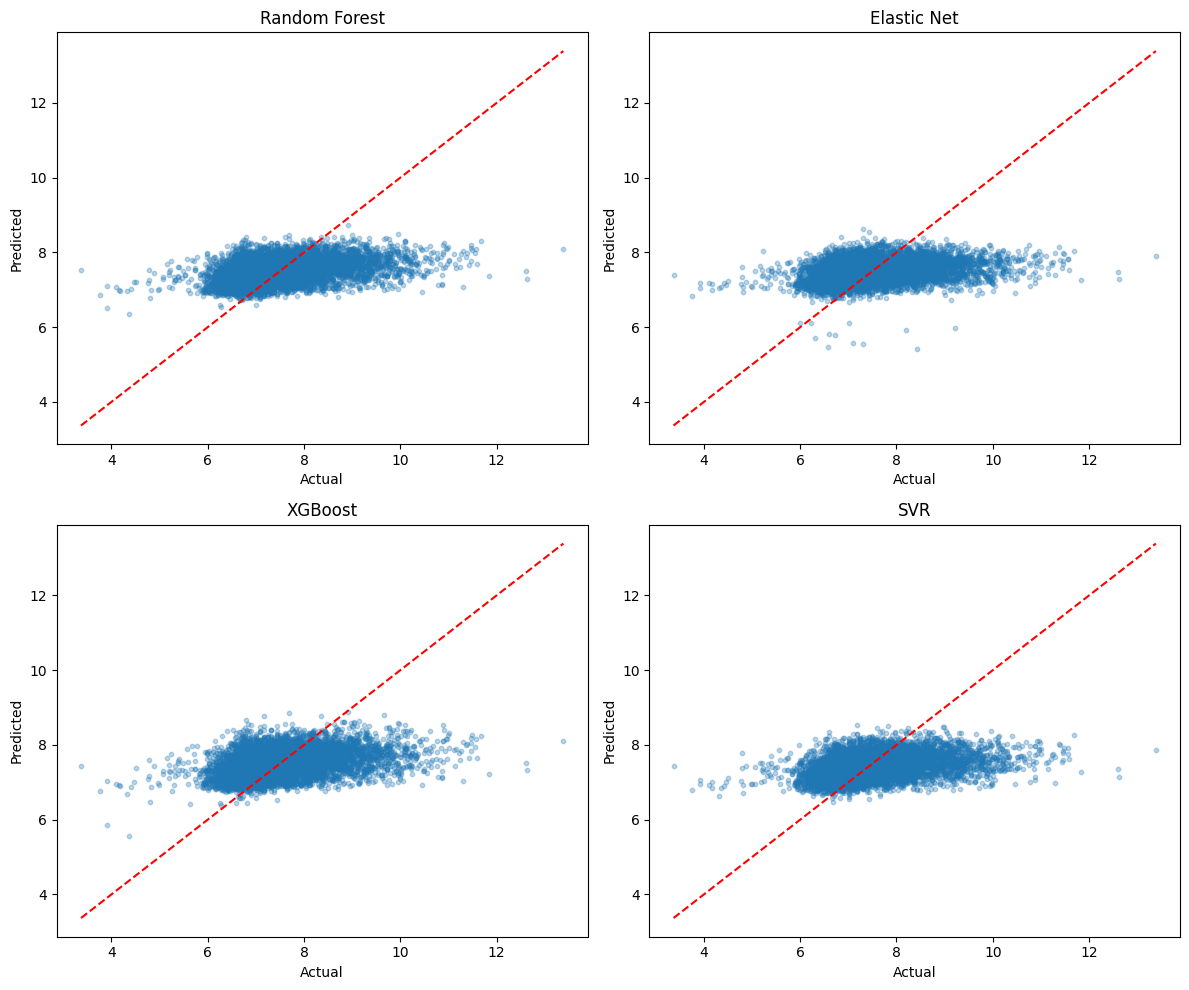

In [ ]:
tuned_models = [
    ("Random Forest", best_rf),
    ("Elastic Net", best_enet),
    ("XGBoost", best_xgb),
    ("SVR", best_svr),
]

n_cols = 2
n_rows = int(np.ceil(len(tuned_models) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = np.array(axes).flatten()

y_min, y_max = y_test.min(), y_test.max()

for i, (name, model) in enumerate(tuned_models):
    y_pred = model.predict(X_test)
    ax = axes[i]
    ax.scatter(y_test, y_pred, alpha=0.3, s=10)
    ax.plot([y_min, y_max], [y_min, y_max], color="red", linestyle="--")
    ax.set_title(name)
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")

for j in range(len(tuned_models), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


# 7. Conclusions